Machine translation (MT) is the automated process of using software to translate text or speech from one natural language to another without human involvement.

We’ll be working with an English-to-Spanish translation dataset available at
www.manythings.org/anki/.

In [1]:
#Downloading the dataset
!wget https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
!unzip -q spa-eng.zip

--2026-03-29 08:28:23--  https://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.129.207, 192.178.210.207, 74.125.126.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.129.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2638744 (2.5M) [application/zip]
Saving to: ‘spa-eng.zip’

spa-eng.zip         100%[===================>]   2.52M  --.-KB/s    in 0.02s   

2026-03-29 08:28:23 (145 MB/s) - ‘spa-eng.zip’ saved [2638744/2638744]



The text file contains one example per line: an English sentence, followed by a tab
character, followed by the corresponding Spanish sentence. Let’s parse this file.

## Getting data ready:

In [2]:
text_file = '/kaggle/working/spa-eng/spa.txt'
with open(text_file) as f:
    lines = f.read().split('\n') [:-1]
text_pairs = []

for line in lines:
    english,spanish = line.split('\t')
    spanish = "[start] " + spanish + " [end]" 
    text_pairs.append((english,spanish))

[start] and [end] are special tokens, often called start token and end token

This helps the model understand:
* Where the sentence starts
* Where the sentence ends
* When to stop generating output

Lets look at one of our text_pairs:

In [3]:
import random 
print(random.choice(text_pairs))

('I have no wife.', '[start] No tengo esposa. [end]')


In [4]:
print('total number of samples: ',len(text_pairs))

total number of samples:  118964


In [5]:
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples

train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_samples = text_pairs = text_pairs[num_train_samples + num_val_samples:]

## Vectorizing the English and Spanish text pairs:
let’s prepare two separate TextVectorization layers: one for English and one
for Spanish. We’re going to need to customize the way strings are preprocessed:
* We need to preserve the "[start]" and "[end]" tokens that we’ve inserted. By
default, the characters [ and ] would be stripped, but we want to keep them
around so we can tell apart the word “start” and the start token "[start]".
* Punctuation is different from language to language! In the Spanish Text
Vectorization layer, if we’re going to strip punctuation characters, we need to
also strip the character ¿.

Note that for a non-toy translation model, we would treat punctuation characters as sep
arate tokens rather than stripping them. In our case, for simplicity, we’ll get rid of all punctuation.

In [6]:
import tensorflow as tf
import string 
import re

strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[","")
strip_chars = strip_chars.replace("]","")

def custom_standardization(input_string):
    '''Prepare a custom string standardization function for the Spanish TextVectorization layer: 
    it preserves [ and ] but strips ¿ (as well as all other characters 
    from strings.punctuation)'''
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", "")

vocab_size = 15000 #to keep it simple
sequence_length = 20 #to keep it simple

#the English layer
source_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens = vocab_size,
    output_mode = 'int',
    output_sequence_length = sequence_length,
)

#the Spanish layer
target_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens = vocab_size,
    output_mode = 'int',
    output_sequence_length = sequence_length + 1,
    standardize = custom_standardization,
)

train_english_texts = [pair[0] for pair in text_pairs]
train_spanish_texts = [pair[1] for pair in text_pairs]

source_vectorizer.adapt(train_english_texts)
target_vectorizer.adapt(train_spanish_texts)

2026-03-29 08:28:25.835145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774772906.054034      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774772906.134994      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774772906.663469      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774772906.663529      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774772906.663532      55 computation_placer.cc:177] computation placer alr

## Preparing dataset objects

In [7]:
batch_size = 64

def format_dataset(eng,spa):
    eng = source_vectorizer(eng)
    spa = target_vectorizer(spa)
    return((
        eng,
        spa[:,:-1] #Take all rows, Take all columns except the last one
        ), spa[:,1:]) #Take all rows, Take all columns except the first one

''' Why do we shift the Spanish sentence?
Because, 
We want the model to learn:
Input Spanish word → Predict next Spanish word'''

def make_dataset(pairs):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).prefetch(16).cache()

In [8]:
train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

In [9]:
#Here’s what our dataset outputs look like:

for inputs, targets in train_ds.take(1):
    print(f"inputs['english'].shape: {inputs[0].shape}")
    print(f"inputs['spanish'].shape: {inputs[1].shape}")
    print(f"targets.shape: {targets.shape}")

inputs['english'].shape: (64, 20)
inputs['spanish'].shape: (64, 20)
targets.shape: (64, 20)


## Transformer Architecture:

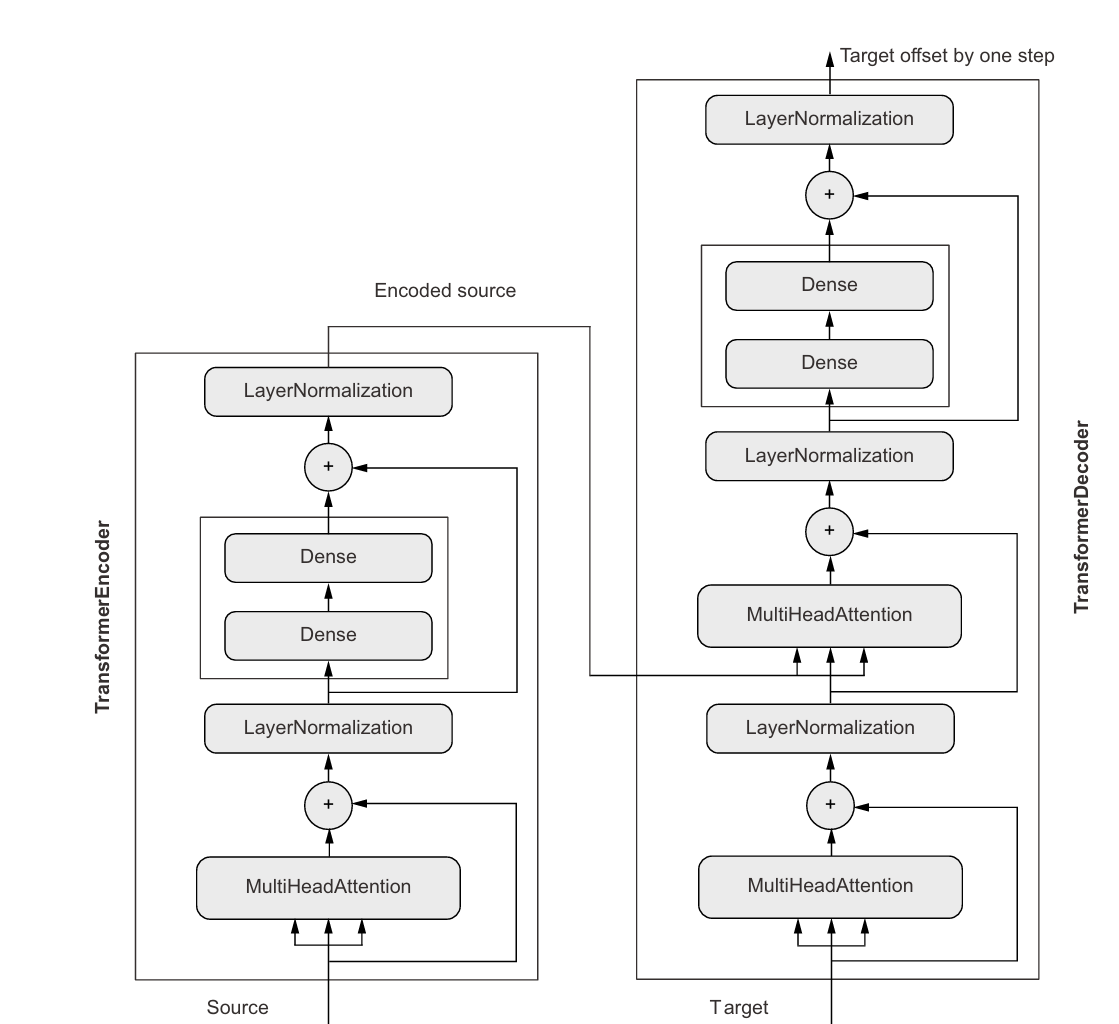

In [10]:
from IPython.display import Image
Image(filename='/kaggle/input/datasets/adwaittagalpallewar/archictecture/architecture.png')

##  Implementing Encoder:
First we implement the Dense → Dense block from the diagram/ feed forward network on the encoder side

In [11]:
def point_wise_ffn(d_model, dff):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(dff, activation='relu'),
        tf.keras.layers.Dense(d_model)
    ])

* d_model = embedding size (like 128, 256, 512)/ number of dimensions of the vector which represents the word in teh embedding space
* dff = hidden layer size (usually 4 × d_model)

Now we implement the encoder class:

In [12]:
from tensorflow.keras.layers import MultiHeadAttention

#encoder layer 
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self,d_model,num_heads,dff):
        super().__init__()

        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.ffn = point_wise_ffn(d_model,dff)

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    #forward pass:
    def call(self, x, mask):
            
        attn_output = self.mha(query=x, key=x, value=x, attention_mask=mask)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

In [13]:
import numpy as np

#positional encoding
def get_angles(pos, i, d_model):
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    return pos * angle_rates

def positional_encoding(position, d_model):
    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],
        np.arange(d_model)[np.newaxis, :],
        d_model
    )

    # sin on even indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # cos on odd indices
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)

In [14]:
#Encoder
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff,
                vocab_size, maximum_position_encoding):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        #embedding layer
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        #positional encoding layer
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)

        #stack of encoder_layers
        self.enc_layers = [
            EncoderLayer(d_model, num_heads, dff)
            for _ in range(self.num_layers)
        ]

        self.dropout = tf.keras.layers.Dropout(0.1)

    #forward pass:
    def call(self, x, training=None, mask=None):
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)  #converting token id's to embeddings
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32)) #scaling embeddings

        x += self.pos_encoding[:, :seq_len, :] #adding positional_encoding with embeddings
        x = self.dropout(x, training=training)

        #passing through encoder layers
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, mask=mask)

        return x

In [15]:
#testing the encoder
sample_encoder = Encoder(
    num_layers=2,
    d_model=128,
    num_heads=8,
    dff=512,
    vocab_size=8000,
    maximum_position_encoding=1000
)

sample_input = tf.random.uniform((32, 20))
mask = None

output = sample_encoder(sample_input, mask)

print(output.shape)

(32, 20, 128)


## Implementing Decoder:
Decoder layer is similar to encoder but has TWO attention blocks

In [16]:
#decoder layer
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff):
        super().__init__()

        self.mha1 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.mha2 = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)

        self.ffn = point_wise_ffn(d_model, dff)

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    #forward pass
    def call(self, x, enc_output, padding_mask=None, look_ahead_mask=None):
        attn1 = self.mha1(query=x, key=x, value=x, attention_mask=look_ahead_mask)
        out1 = self.layernorm1(x + attn1)

        attn2 = self.mha2(query=out1, key=enc_output, value=enc_output, attention_mask=padding_mask)
        out2 = self.layernorm2(out1 + attn2)

        x = self.ffn(out2)
        out3 = self.layernorm3(out2 + x)

        return out3

In [17]:
#Decoder
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff,
                vocab_size, maximum_position_encoding):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)

        self.dec_layers = [
            DecoderLayer(d_model, num_heads, dff)
            for _ in range(num_layers)
        ]

        self.dropout = tf.keras.layers.Dropout(0.1)

    #forward pass
    def call(self, x, enc_output, training=False, padding_mask=None, look_ahead_mask=None):
        seq_len = tf.shape(x)[1]

        # Embedding
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        # Positional encoding
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)

        # Pass through decoder layers
        for i in range(self.num_layers):
            x = self.dec_layers[i](
                x,
                enc_output,
                training=training,
                padding_mask=mask,
                look_ahead_mask=look_ahead_mask
            )

        return x

In [18]:
#test decoder
sample_decoder = Decoder(
    num_layers=2,
    d_model=128,
    num_heads=8,
    dff=512,
    vocab_size=8000,
    maximum_position_encoding=1000
)

x = tf.random.uniform((32, 20))
enc_output = tf.random.uniform((32, 20, 128))

out = sample_decoder(
    x,
    enc_output,
    training=False,
    padding_mask=None,
    look_ahead_mask=None
)

print(out.shape)

(32, 20, 128)


## Trnsformer Class:
This is where we combine all the pieces we have been building so far (encoder, decoder) with a final linear layer
* Transformer = Encoder + Decoder + Final Linear Layer

In [19]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                input_vocab_size, target_vocab_size, 
                pe_input, pe_target):
        super().__init__()

        self.encoder = Encoder(
            num_layers, d_model, num_heads, dff,
            input_vocab_size, pe_input)
        
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                              target_vocab_size, pe_target)

        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inp, tar, training=False,
            enc_padding_mask=None,
            look_ahead_mask=None,
            dec_padding_mask=None):

        #encoder output
        enc_output = self.encoder(inp, training=training, mask=enc_padding_mask)
        
        #decoder output
        dec_output = self.decoder(tar, enc_output, training=training, 
                                  padding_mask=dec_padding_mask, look_ahead_mask=look_ahead_mask)

        #final linear layer
        final_output = self.final_layer(dec_output)

        return final_output

In [20]:
#test transformer
sample_transformer = Transformer(
    num_layers=2,
    d_model=128,
    num_heads=8,
    dff=512,
    input_vocab_size=8000,
    target_vocab_size=8000,
    pe_input=1000,
    pe_target=1000
)

inp = tf.random.uniform((32, 20))
tar = tf.random.uniform((32, 20))

out = sample_transformer(
    inp,
    tar,
    training=False,
    enc_padding_mask=None,
    look_ahead_mask=None,
    dec_padding_mask=None
)

print(out.shape)

(32, 20, 8000)


Mathematically the whole idea is: **P(next_word | previous_words, input_sentence)**

## Creating masks:

In [21]:
#padding mask
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    
    # add extra dimensions for attention
    return seq[:, tf.newaxis, tf.newaxis, :]

#look ahead mask
def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask

def create_masks(inp, tar):
    
    # Encoder padding mask
    enc_padding_mask = create_padding_mask(inp)
    
    # Decoder padding mask (used in cross attention)
    dec_padding_mask = create_padding_mask(inp)
    
    # Look ahead mask
    look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])
    
    # Target padding mask
    dec_target_padding_mask = create_padding_mask(tar)
    
    # Combine both
    combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)
    
    return enc_padding_mask, combined_mask, dec_padding_mask

In [22]:
#transformer model class
class TransformerModel(tf.keras.Model):
    def __init__(self, transformer):
        super().__init__()
        self.transformer = transformer

    def call(self, inputs, training=None):
        inp, tar_inp = inputs

        enc_padding_mask, look_ahead_mask, dec_padding_mask = create_masks(inp, tar_inp)

        return self.transformer(
            inp,
            tar_inp,
            training=training,
            enc_padding_mask=enc_padding_mask,
            look_ahead_mask=look_ahead_mask,
            dec_padding_mask=dec_padding_mask
        )

## Training:

In [23]:
#loss function
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
)

def loss_function(real, pred):
    loss = loss_object(real, pred)

    mask = tf.cast(tf.not_equal(real, 0), tf.float32)
    loss *= mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

#optimizar
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.9,
    beta_2=0.98,
    epsilon=1e-9
)

#metric
def masked_accuracy(real, pred):
    '''Token wise accuracy insted of whole sentence whise'''
    pred_ids = tf.argmax(pred, axis=2)
    
    mask = tf.cast(tf.not_equal(real, 0), tf.float32)
    
    matches = tf.cast(tf.equal(real, pred_ids), tf.float32)
    matches *= mask
    
    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

In [24]:
tf.config.run_functions_eagerly(False)

#model
transformer = Transformer(
    num_layers=4,
    d_model=128,
    num_heads=8,
    dff=512,
    input_vocab_size=vocab_size,
    target_vocab_size=vocab_size,
    pe_input=1000,
    pe_target=1000,
)

model = TransformerModel(transformer)

model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=[masked_accuracy]
)

In [25]:
#callbacks 
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("best_transformer.keras", save_best_only=True)
earlystopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [26]:
history = model.fit(train_ds,
              validation_data=val_ds,
              epochs=20,
              callbacks=[checkpoint_cb, earlystopping_cb])

Epoch 1/20


I0000 00:00:1774772968.290779     130 service.cc:152] XLA service 0x7dfad0022060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774772968.290823     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774772968.290830     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774772972.631358     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/1302 ━━━━━━━━━━━━━━━━━━━━ 1:06 51ms/step - loss: 9.6073 - masked_accuracy: 0.0000e+00   

I0000 00:00:1774772982.482586     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1302/1302 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - loss: 6.4837 - masked_accuracy: 0.2172 - val_loss: 2.7287 - val_masked_accuracy: 0.6208
Epoch 2/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - loss: 2.3859 - masked_accuracy: 0.6657 - val_loss: 1.5012 - val_masked_accuracy: 0.7984
Epoch 3/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - loss: 1.3811 - masked_accuracy: 0.8137 - val_loss: 0.9565 - val_masked_accuracy: 0.8797
Epoch 4/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - loss: 0.8953 - masked_accuracy: 0.8847 - val_loss: 0.6596 - val_masked_accuracy: 0.9247
Epoch 5/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - loss: 0.6210 - masked_accuracy: 0.9256 - val_loss: 0.4866 - val_masked_accuracy: 0.9515
Epoch 6/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - loss: 0.4496 - masked_accuracy: 0.9508 - val_loss: 0.3709 - val_masked_accuracy: 0.9684
Epoch 7/20
1302/1302 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - loss: 0.3366 - masked_accuracy: 0.9674 - val_loss: 0.2954 - val_masked_accur

## Translation function:

In [37]:
spa_vocab = target_vectorizer.get_vocabulary()

start_token = spa_vocab.index("[start]")
end_token = spa_vocab.index("[end]")

print(start_token, end_token)

2 3


In [44]:
def translate(sentence, max_len=40, temperature=1.0):
    # tokenize input
    encoder_input = source_vectorizer([sentence])

    # start token
    decoder_input = tf.constant([[start_token]])

    for i in range(max_len):
        predictions = model([encoder_input, decoder_input], training=False)
        predictions = predictions[:, -1, :]  # last step logits

        # apply temperature
        predictions = predictions / temperature

        # sample next token
        predicted_id = tf.random.categorical(tf.math.log(predictions), num_samples=1)
        predicted_id = tf.cast(tf.squeeze(predicted_id, axis=-1), tf.int32)

        # append to decoder input
        decoder_input = tf.concat(
            [decoder_input, tf.expand_dims(predicted_id, 1)],
            axis=1
        )

        # stop if end token generated
        if predicted_id.numpy()[0] == end_token:
            break

    return decoder_input

In [56]:
def decode_tokens(token_ids, tokenizer):
    vocab = tokenizer.get_vocabulary()
    words = []
    for tid in token_ids:
        if tid == 0 or tid == start_token:
            continue
        if tid == end_token:
            break
        # safe lookup
        tid = min(tid, len(vocab) - 1)
        words.append(vocab[tid])
    return ' '.join(words)

In [59]:
tokens = translate("i am a student")
print(tokens)
print(decode_tokens(tokens[0], target_vectorizer))

tf.Tensor(
[[   2    0 4765  707    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]], shape=(1, 41), dtype=int32)
comienzo debemos
